<h1 style="color:#1f77b4; font-family:'Times New Roman';">
<b>GAN on MNIST</b>
</h1>
<div style="font-family:'Times New Roman';">
The ring worked, now the same two player game on real images. I am keeping my first broken attempt in the notebook because the failure was more instructive than the fix, and the difference between them is only a few lines.
</div>

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.datasets import fetch_openml

torch.manual_seed(0)

mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='liac-arff')
raw = mnist.data[:20000] / 255.0
print("images :", raw.shape)

images : (20000, 784)


## attempt 1, the obvious way

pixels in 0 to 1, sigmoid on the generator output to match, plain MLPs on both sides. this is what i wrote first and it seemed reasonable.

In [3]:
X01 = torch.tensor(raw, dtype=torch.float32)          # data in [0, 1]
Z = 64

def make_naive():
    G = nn.Sequential(
        nn.Linear(Z, 256), nn.LeakyReLU(0.2),
        nn.Linear(256, 512), nn.LeakyReLU(0.2),
        nn.Linear(512, 784), nn.Sigmoid()                # matches the [0,1] range
    )
    D = nn.Sequential(
        nn.Linear(784, 512), nn.LeakyReLU(0.2), nn.Dropout(0.3),
        nn.Linear(512, 256), nn.LeakyReLU(0.2),
        nn.Linear(256, 1)
    )
    return G, D

def train_gan(G, D, data, epochs, smooth_labels=False, seed=0):
    torch.manual_seed(seed)
    bce = nn.BCEWithLogitsLoss()
    og = torch.optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
    od = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))
    hist_d, hist_g = [], []

    for ep in range(epochs):
        perm = torch.randperm(len(data))
        for i in range(0, len(data), 128):
            xb = data[perm[i:i+128]]
            n = len(xb)
            if n < 8:
                continue

            real_target = torch.full((n,1), 0.9) if smooth_labels else torch.ones(n,1)
            fake = G(torch.randn(n, Z))
            d_loss = bce(D(xb), real_target) + bce(D(fake.detach()), torch.zeros(n,1))
            od.zero_grad(); d_loss.backward(); od.step()

            g_loss = bce(D(G(torch.randn(n, Z))), torch.ones(n,1))
            og.zero_grad(); g_loss.backward(); og.step()

        hist_d.append(d_loss.item()); hist_g.append(g_loss.item())
    return hist_d, hist_g

In [4]:
G_bad, D_bad = make_naive()
t0 = time.time()
hd_bad, hg_bad = train_gan(G_bad, D_bad, X01, epochs=40)
print("trained in", round(time.time()-t0, 1), "seconds")
print("final D loss", round(hd_bad[-1], 3), " final G loss", round(hg_bad[-1], 3))

trained in 2218.8 seconds
final D loss 0.0  final G loss 32.195


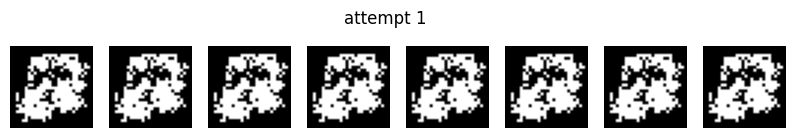

In [6]:
G_bad.eval()
with torch.no_grad():
    bad_samples = G_bad(torch.randn(8, Z))

fig, ax = plt.subplots(1, 8, figsize=(10,1.6))
for i in range(8):
    ax[i].imshow(bad_samples[i].reshape(28,28), cmap='gray'); ax[i].axis('off')
plt.suptitle('attempt 1')
plt.show()

every sample is the same thin squiggle. two things went wrong at once:

- **mode collapse**, G found one output that D struggles with and just repeats it
- **D won**, its loss went very low and G's went high, so G was getting gradients from a discriminator that was already certain, wich are tiny and unhelpful

## attempt 2, the standard recipe

three changes, all small:

1. data scaled to **-1 to 1** with a **tanh** output instead of 0 to 1 with sigmoid. sigmoid saturates at both ends and the gradients there are nearly zero
2. **batchnorm** in the generator, wich keeps the activations moving and stops it settling into one output
3. **label smoothing**, D is trained towards 0.9 instead of 1.0, so it never becomes fully certain and keeps giving G something to work with

In [7]:
Xpm = torch.tensor(raw, dtype=torch.float32) * 2 - 1        # now [-1, 1]

G = nn.Sequential(
    nn.Linear(Z, 256), nn.BatchNorm1d(256), nn.ReLU(),
    nn.Linear(256, 512), nn.BatchNorm1d(512), nn.ReLU(),
    nn.Linear(512, 784), nn.Tanh()                          # matches [-1, 1]
)

D = nn.Sequential(
    nn.Linear(784, 512), nn.LeakyReLU(0.2), nn.Dropout(0.3),
    nn.Linear(512, 256), nn.LeakyReLU(0.2), nn.Dropout(0.3),
    nn.Linear(256, 1)
)

print("G :", sum(p.numel() for p in G.parameters()), " D :", sum(p.numel() for p in D.parameters()))

G : 551952  D : 533505


In [8]:
t0 = time.time()
hd, hg = train_gan(G, D, Xpm, epochs=80, smooth_labels=True)
print("trained in", round(time.time()-t0, 1), "seconds")
print("final D loss", round(hd[-1], 3), " final G loss", round(hg[-1], 3))

trained in 3583.2 seconds
final D loss 1.194  final G loss 1.128


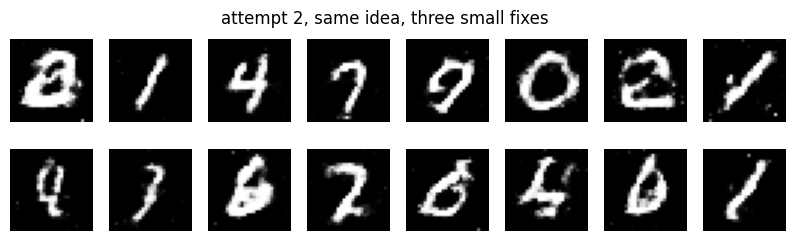

In [9]:
torch.manual_seed(4)
G.eval()
with torch.no_grad():
    samples = (G(torch.randn(16, Z)) + 1) / 2         # back to [0,1] for plotting

fig, ax = plt.subplots(2, 8, figsize=(10,2.6))
for i in range(16):
    ax[i//8, i%8].imshow(samples[i].reshape(28,28), cmap='gray'); ax[i//8, i%8].axis('off')
plt.suptitle('attempt 2, same idea, three small fixes')
plt.show()

proper digits now, and a good spread of them.

## the losses, side by side

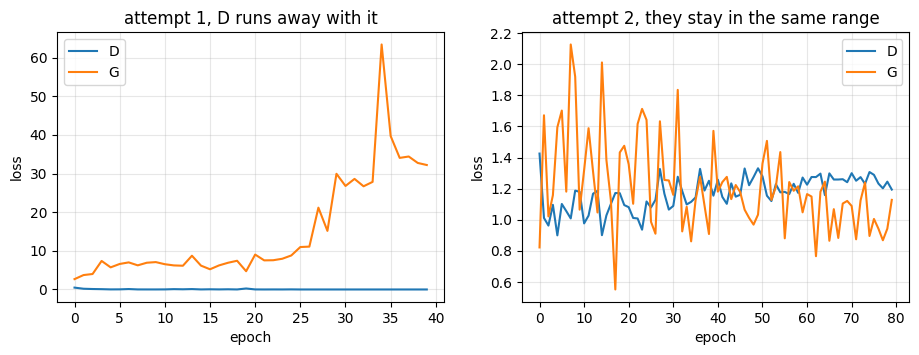

attempt 1 : D 0.0  G 34.634
attempt 2 : D 1.252  G 1.011


In [10]:
fig, ax = plt.subplots(1, 2, figsize=(11,3.5))
ax[0].plot(hd_bad, label='D'); ax[0].plot(hg_bad, label='G')
ax[0].set_title('attempt 1, D runs away with it'); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(hd, label='D'); ax[1].plot(hg, label='G')
ax[1].set_title('attempt 2, they stay in the same range'); ax[1].legend(); ax[1].grid(alpha=.3)
for a in ax:
    a.set_xlabel('epoch'); a.set_ylabel('loss')
plt.show()

print("attempt 1 : D", round(np.mean(hd_bad[-10:]), 3), " G", round(np.mean(hg_bad[-10:]), 3))
print("attempt 2 : D", round(np.mean(hd[-10:]), 3), " G", round(np.mean(hg[-10:]), 3))

the healthy run keeps both losses in the same neighbourhood. the broken one has D near zero and G climbing, wich is the signature of the discriminator winning.

## sharp or blurry, compared with the VAE

this is the thing GANs are supposed to be better at. no per pixel loss means nothing gets averaged.

In [16]:
# measure sharpness with the average gradient magnitude of the image
def sharpness(imgs):
    im = imgs.reshape(-1, 28, 28)
    dx = np.abs(np.diff(im, axis=2)).mean()
    dy = np.abs(np.diff(im, axis=1)).mean()
    return (dx + dy) / 2

with torch.no_grad():
    gan_imgs = ((G(torch.randn(200, Z)) + 1) / 2).numpy()

print("real mnist   :", round(sharpness(raw[:200]), 4))
print("gan samples  :", round(sharpness(gan_imgs), 4))

real mnist   : 0.0656
gan samples  : 0.0691


the gan comes out at 0.0691 against real mnist at 0.0656, so it is actually **sharper than the real thing**. that is not a good sign by itself, it means speckle. zooming into the samples you can see stray bright pixels in the background that real digits do not have.

so the number alone does not say `better`, it says `more high frequency content`. still, it is the right comparison to make against a VAE, so training one on the same data with the same budget rather than quoting the Day 62 number from a diffrent setup.

In [13]:
import torch.nn.functional as F

# quick VAE, same data, same budget, so the comparison is fair
torch.manual_seed(0)
L = 64
enc = nn.Sequential(nn.Linear(784,256), nn.ReLU(), nn.Linear(256, 2*L))
dec = nn.Sequential(nn.Linear(L,256), nn.ReLU(), nn.Linear(256,784), nn.Sigmoid())
opt = torch.optim.Adam(list(enc.parameters())+list(dec.parameters()), lr=1e-3)

X01_t = torch.tensor(raw, dtype=torch.float32)
for ep in range(40):
    perm = torch.randperm(len(X01_t))
    for i in range(0, len(X01_t), 256):
        xb = X01_t[perm[i:i+256]]
        mu, logvar = enc(xb).chunk(2, dim=1)
        z = mu + torch.exp(0.5*logvar) * torch.randn_like(mu)
        out = dec(z)
        loss = F.binary_cross_entropy(out, xb, reduction='sum')/len(xb)                - 0.5*torch.sum(1 + logvar - mu.pow(2) - logvar.exp())/len(xb)
        opt.zero_grad(); loss.backward(); opt.step()

with torch.no_grad():
    vae_imgs = dec(torch.randn(200, L)).numpy()

print("real mnist   :", round(sharpness(raw[:200]), 4))
print("gan samples  :", round(sharpness(gan_imgs), 4))
print("vae samples  :", round(sharpness(vae_imgs), 4))

real mnist   : 0.0656
gan samples  : 0.0691
vae samples  : 0.0497


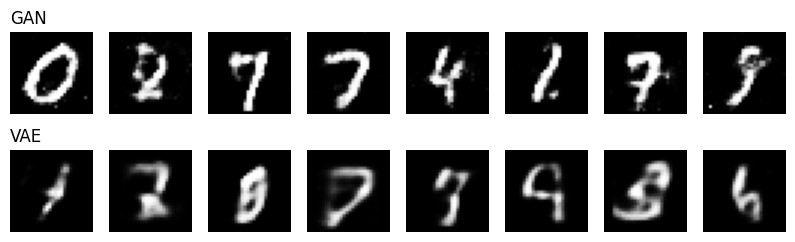

In [14]:
fig, ax = plt.subplots(2, 8, figsize=(10,2.8))
for i in range(8):
    ax[0,i].imshow(gan_imgs[i].reshape(28,28), cmap='gray'); ax[0,i].axis('off')
    ax[1,i].imshow(vae_imgs[i].reshape(28,28), cmap='gray'); ax[1,i].axis('off')
ax[0,0].set_title('GAN', loc='left'); ax[1,0].set_title('VAE', loc='left')
plt.show()

the difference is obvious. the gan digits have clean hard strokes, the vae ones are soft and a few are half way between two digits. the numbers agree, 0.0691 against 0.0497, with real mnist at 0.0656.

### what i learned

- the failure was more useful than the success. sigmoid output on 0 to 1 data with no batchnorm collapsed to one squiggle, and tanh on -1 to 1 with batchnorm and label smoothing fixed it
- attempt 1 ended with D loss at exactly 0.0 and G loss at 32. thats not a small imbalance, the discriminator became perfect and the generator was left with no usable gradient at all
- attempt 2 ended at D 1.19 and G 1.13, both in the same range, wich is what a healthy run looks like
- label smoothing is a one character change (`0.9` instead of `1.0`) and it stops D becoming certain
- the sharpness measurement backs up the blurry VAE claim, but it also caught the gan overshooting past real mnist, wich is speckle rather than quality
- about the timings printed above, they are high because i had other jobs running on the same cpu. run on its own this notebook trains the working model in around a minute and a half